# Low fidelity model SMC testing

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

from scipy.stats import uniform, multivariate_normal

sys.path.append(os.path.join(os.getcwd(), "../../"))
from smcpy.mcmc.vector_mcmc import VectorMCMC
from smcpy.mcmc.vector_mcmc_kernel import VectorMCMCKernel
from smcpy import AdaptiveSampler as Sampler
from smcpy.paths import GeometricPath

from toy_helpers import M_HF, M_LF, generate_noisy_data

In [13]:
# Data generation details
STD_DEV = 0.2
theta_0 = 1/20
theta_1 = 1
THETA_TRUE = np.array([[theta_0, theta_1]])
NUM_PARTICLES = 10_000

In [14]:
def plot_target_boxplots(true_values, **series):
    """Plot box plots for each parameter and series over the phi sequence.

    Args:
        true_values: array-like of true parameter values in param order
        **series: label=(targets_list, phi_sequence) for each SMC run
    """
    first_targets, _ = next(iter(series.values()))
    param_names = first_targets[0].param_names
    n_params = len(param_names)
    n_series = len(series)

    fig, axes = plt.subplots(
        n_params,
        n_series,
        sharex="col",
        sharey="row",
        figsize=(4 * n_series, 3 * n_params),
    )
    axes = np.atleast_2d(axes)

    for col, (label, (targets, phi_sequence)) in enumerate(series.items()):
        positions = np.arange(len(phi_sequence))
        box_width = 0.6
        for row, (name, true_val) in enumerate(zip(param_names, true_values)):
            ax = axes[row, col]
            ax.boxplot(
                [target.params[:, row] for target in targets],
                positions=positions,
                widths=box_width,
                patch_artist=True,
                manage_ticks=False,
            )
            ax.axhline(
                true_val,
                color="r",
                linestyle="--",
                linewidth=1.5,
                label="true value",
                alpha=0.7,
            )
            ax.grid(True)
            if col == 0:
                ax.set_ylabel(f"${name}$")
        axes[0, col].set_title(label + f" ({len(targets)} steps)")

    for col in range(n_series):
        axes[-1, col].set_xlabel("step")

    axes[0, -1].legend(loc="upper right")
    plt.tight_layout()
    plt.savefig("low_fidelity_test.png")
    plt.show()

In [15]:
np.random.seed(42)
noisy_data = generate_noisy_data(THETA_TRUE, STD_DEV)

## Approach 1

In [16]:
priors = [uniform(0, 1), uniform(-2, 4)]
vector_mcmc = VectorMCMC(M_LF, noisy_data, priors, STD_DEV)

# initialize from prior
mcmc_kernel = VectorMCMCKernel(vector_mcmc, param_order=("theta_0", "theta_1"))
smc = Sampler(mcmc_kernel=mcmc_kernel, show_progress_bar=True)
reg_step_list, mll_list = smc.sample(
    num_particles=NUM_PARTICLES,
    num_mcmc_samples=5,
    target_ess=0.5
)
reg_phi_list = smc.phi_sequence

[ mutation ratio: 0.9808: : 100.00%|██████████| phi: 1.00000/1.0 [01:18<00:00  


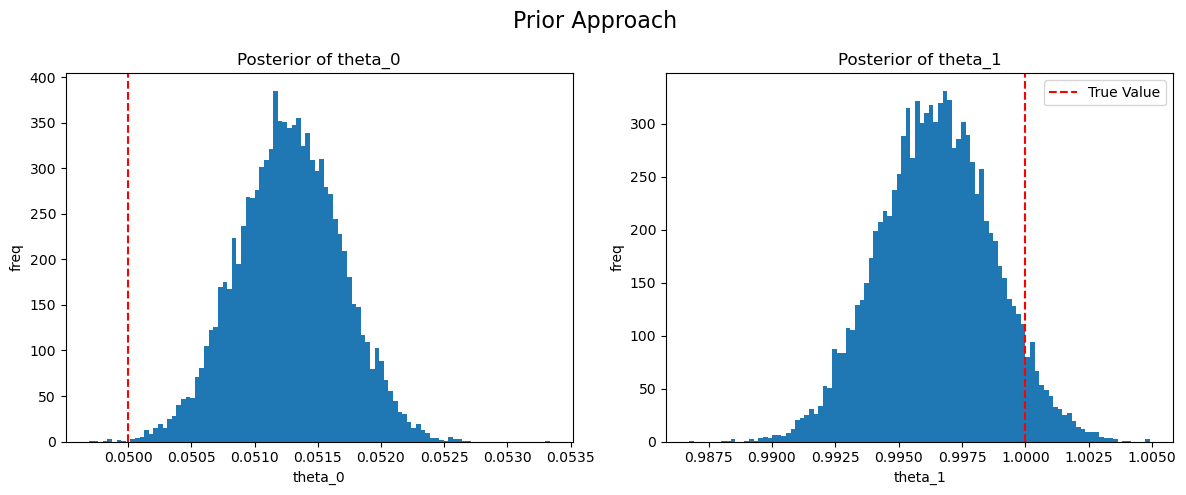

In [17]:
# Create a 1x2 subplot figure (adjust figsize as needed)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Add the Main Title ---
fig.suptitle('Prior Approach', fontsize=16)

# --- Plot 1: theta_0 ---
axes[0].hist(reg_step_list[-1].params[:, 0], bins=100, density=False)
axes[0].axvline(theta_0, color='red', linestyle='--', label='True Value')
axes[0].set_xlabel('theta_0')
axes[0].set_ylabel('freq')
axes[0].set_title('Posterior of theta_0')

# --- Plot 2: theta_1 ---
axes[1].hist(reg_step_list[-1].params[:, -1], bins=100, density=False)
axes[1].axvline(theta_1, color='red', linestyle='--', label='True Value')
axes[1].set_xlabel('theta_1')
axes[1].set_ylabel('freq')
axes[1].set_title('Posterior of theta_1')
axes[1].legend(loc='upper right') 

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the plot
plt.show()

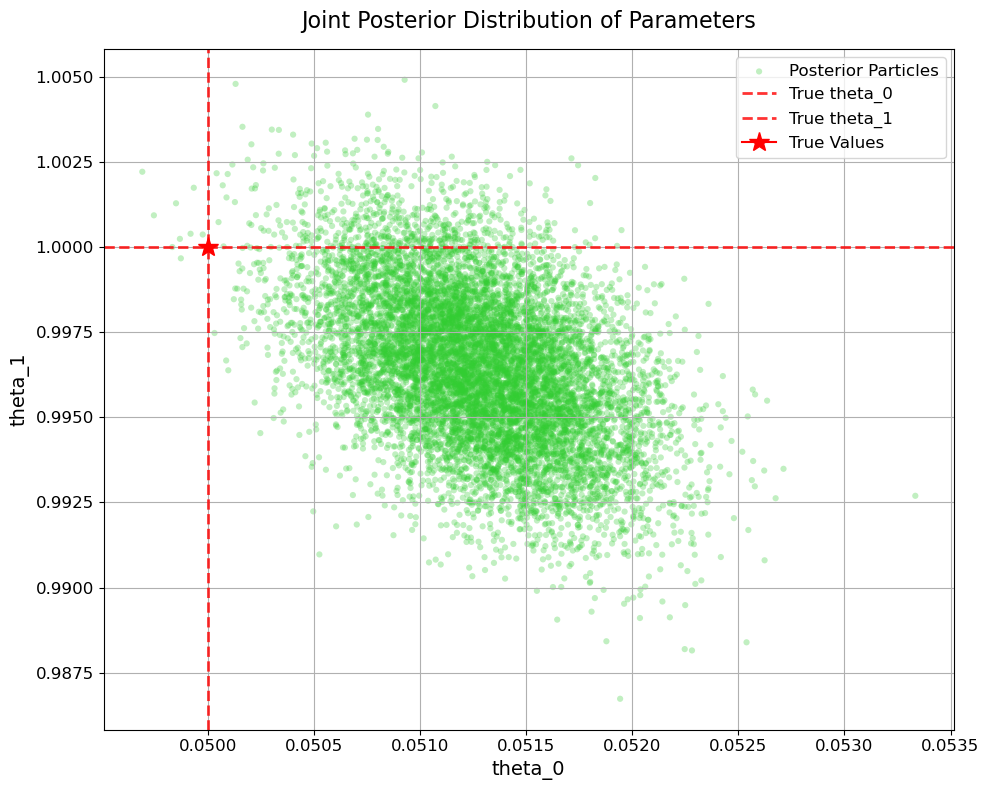

In [20]:
plt.figure(figsize=(10, 8))

# Scatter plot with density styling
plt.scatter(
    reg_step_list[-1].params[:, 0],
    reg_step_list[-1].params[:, 1],
    alpha=0.3,           # Transparency makes overlapping points look darker (shows density)
    s=20,                # Smaller marker size
    color='limegreen',  # A nice, vibrant modern blue
    edgecolors='none',   # Removes the harsh black borders around each dot
    label='Posterior Particles'
)

# Plot the true values as intersecting lines (since you used them in the histograms!)
plt.axvline(theta_0, color='red', linestyle='--', alpha=0.8, linewidth=2, label='True theta_0')
plt.axhline(theta_1, color='red', linestyle='--', alpha=0.8, linewidth=2, label='True theta_1')

# Add a marker right at the exact true value intersection
plt.plot(theta_0, theta_1, marker='*', color='red', markersize=15, label='True Values')

# Labels and Titles with increased font sizes
plt.xlabel('theta_0', fontsize=14)
plt.ylabel('theta_1', fontsize=14)
plt.title('Joint Posterior Distribution of Parameters', fontsize=16, pad=15)

# Add a subtle background grid for readability
plt.grid()

# Make tick marks slightly larger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add the legend
plt.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

In [28]:
# Extract the posterior samples for cleaner referencing
theta_0_samples = reg_step_list[-1].params[:, 0]
theta_1_samples = reg_step_list[-1].params[:, 1]

# Calculate the 2x2 covariance matrix
cov_matrix = np.cov(theta_0_samples, theta_1_samples)
cross_cov = cov_matrix[0, 1]  # The actual covariance between theta_0 and theta_1

# Print the results cleanly
print("--- Posterior Statistics ---")

print("Theta_0:")
print(f"    Mean:  {np.mean(theta_0_samples):.4f}")
print(f"    StDev: {np.std(theta_0_samples):.4f}")

print("\nTheta_1:")
print(f"    Mean:  {np.mean(theta_1_samples):.4f}")
print(f"    StDev: {np.std(theta_1_samples):.4f}")

print("\nCovariance:")
print(f"    Cov(theta_0, theta_1): {cross_cov:.4f}")
print("    Full Matrix:")
print(f"        [[{cov_matrix[0,0]:.4e}, {cov_matrix[0,1]:.4e}]")
print(f"         [{cov_matrix[1,0]:.4e}, {cov_matrix[1,1]:.4e}]]")

--- Posterior Statistics ---
Theta_0:
    Mean:  0.0513
    StDev: 0.0004

Theta_1:
    Mean:  0.9965
    StDev: 0.0023

Covariance:
    Cov(theta_0, theta_1): -0.0000
    Full Matrix:
        [[1.6728e-07, -4.3470e-07]
         [-4.3470e-07, 5.0786e-06]]


## Approach 2

In [29]:
# initialize from proposal
proposal_mean = np.array([np.mean(theta_0_samples), np.mean(theta_1_samples)])
proposal_dist = multivariate_normal(mean=proposal_mean, cov=cov_matrix)

mcmc_kernel = VectorMCMCKernel(
    vector_mcmc, param_order=("theta_0", "theta_1"), path=GeometricPath(proposal=proposal_dist)
)
smc = Sampler(mcmc_kernel=mcmc_kernel, show_progress_bar=True)
prop_step_list, mll_list = smc.sample(
    num_particles=NUM_PARTICLES,
    num_mcmc_samples=5,
    target_ess=0.5
)
prop_phi_list = smc.phi_sequence

[ mutation ratio: 0.9801: : 100.00%|██████████| phi: 1.00000/1.0 [00:07<00:00


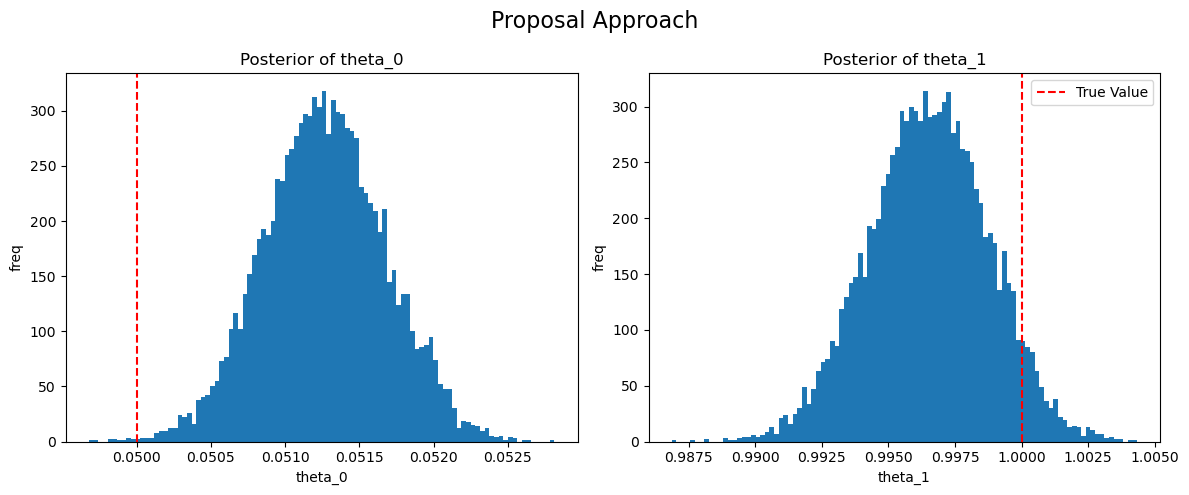

In [30]:
# Create a 1x2 subplot figure (adjust figsize as needed)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Add the Main Title ---
fig.suptitle('Proposal Approach', fontsize=16)

# --- Plot 1: theta_0 ---
axes[0].hist(prop_step_list[-1].params[:, 0], bins=100, density=False)
axes[0].axvline(theta_0, color='red', linestyle='--', label='True Value')
axes[0].set_xlabel('theta_0')
axes[0].set_ylabel('freq')
axes[0].set_title('Posterior of theta_0')

# --- Plot 2: theta_1 ---
axes[1].hist(prop_step_list[-1].params[:, -1], bins=100, density=False)
axes[1].axvline(theta_1, color='red', linestyle='--', label='True Value')
axes[1].set_xlabel('theta_1')
axes[1].set_ylabel('freq')
axes[1].set_title('Posterior of theta_1')
axes[1].legend(loc='upper right') 

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the plot
plt.show()

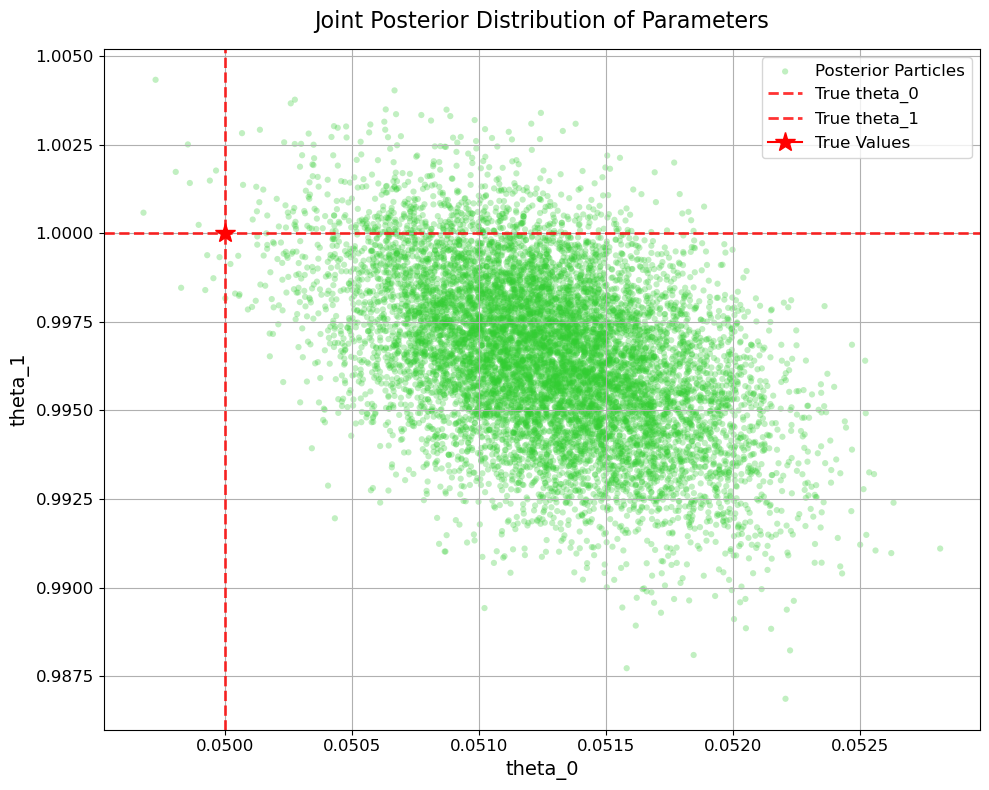

In [32]:
plt.figure(figsize=(10, 8))

# Scatter plot with density styling
plt.scatter(
    prop_step_list[-1].params[:, 0],
    prop_step_list[-1].params[:, 1],
    alpha=0.3,           # Transparency makes overlapping points look darker (shows density)
    s=20,                # Smaller marker size
    color='limegreen',  # A nice, vibrant modern blue
    edgecolors='none',   # Removes the harsh black borders around each dot
    label='Posterior Particles'
)

# Plot the true values as intersecting lines (since you used them in the histograms!)
plt.axvline(theta_0, color='red', linestyle='--', alpha=0.8, linewidth=2, label='True theta_0')
plt.axhline(theta_1, color='red', linestyle='--', alpha=0.8, linewidth=2, label='True theta_1')

# Add a marker right at the exact true value intersection
plt.plot(theta_0, theta_1, marker='*', color='red', markersize=15, label='True Values')

# Labels and Titles with increased font sizes
plt.xlabel('theta_0', fontsize=14)
plt.ylabel('theta_1', fontsize=14)
plt.title('Joint Posterior Distribution of Parameters', fontsize=16, pad=15)

# Add a subtle background grid for readability
plt.grid()

# Make tick marks slightly larger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add the legend
plt.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

## Comparison

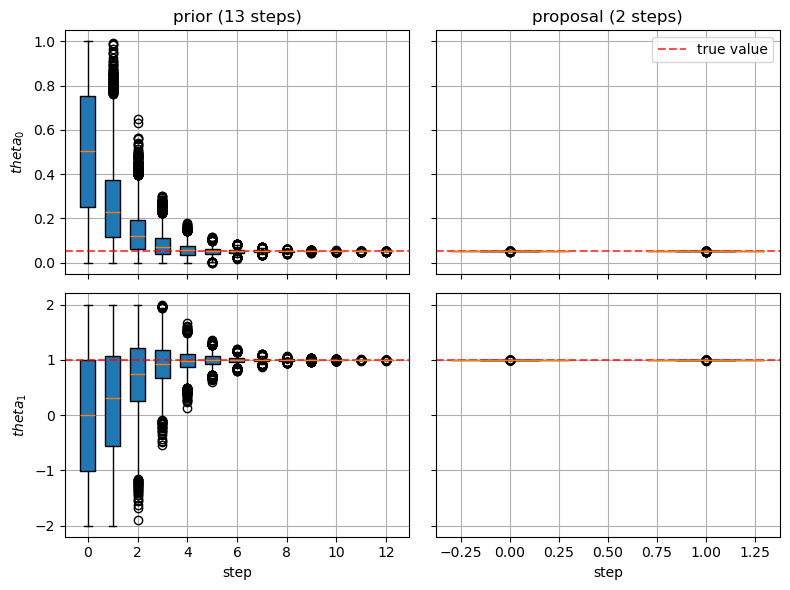

In [31]:
plot_target_boxplots(
    THETA_TRUE.flatten(),
    prior=(reg_step_list, reg_phi_list),
    proposal=(prop_step_list, prop_phi_list),
)